<a href="https://colab.research.google.com/github/Adyan213/Hands-On-ML/blob/main/chapter_2_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jayaantanaath/student-habits-vs-academic-performance")

print("Path to dataset files:", path)

100%|██████████| 19.1k/19.1k [00:00<00:00, 37.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jayaantanaath/student-habits-vs-academic-performance/versions/1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
performance=pd.read_csv(path + "/student_habits_performance.csv")

In [ ]:
performance.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [ ]:
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [ ]:
performance.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'study_hours_per_day'}>,
        <Axes: title={'center': 'social_media_hours'}>],
       [<Axes: title={'center': 'netflix_hours'}>,
        <Axes: title={'center': 'attendance_percentage'}>,
        <Axes: title={'center': 'sleep_hours'}>],
       [<Axes: title={'center': 'exercise_frequency'}>,
        <Axes: title={'center': 'mental_health_rating'}>,
        <Axes: title={'center': 'exam_score'}>]], dtype=object)

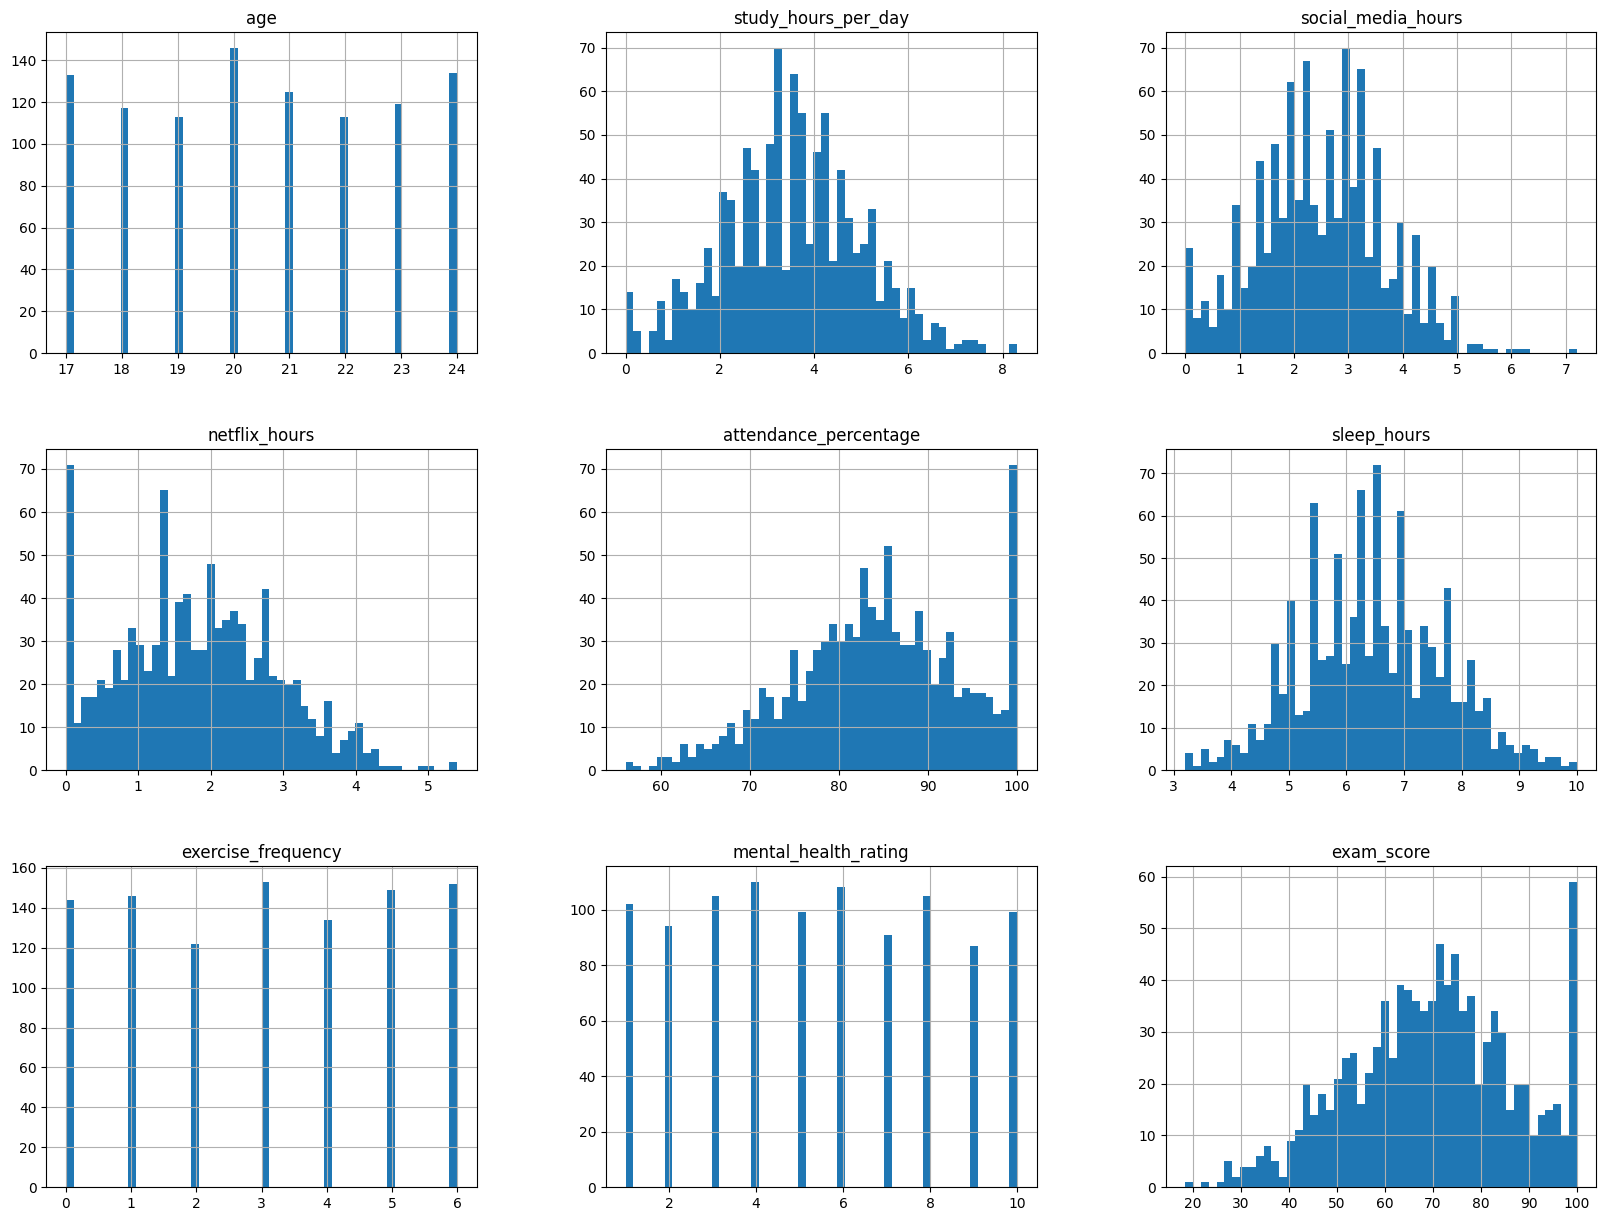

In [ ]:
performance.hist(bins=50, figsize=(20,15))

In [ ]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="most_frequent")

In [ ]:
X=imputer.fit_transform(performance)

In [ ]:
performance=pd.DataFrame(X,columns=performance.columns)

In [ ]:
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   student_id                     1000 non-null   object
 1   age                            1000 non-null   object
 2   gender                         1000 non-null   object
 3   study_hours_per_day            1000 non-null   object
 4   social_media_hours             1000 non-null   object
 5   netflix_hours                  1000 non-null   object
 6   part_time_job                  1000 non-null   object
 7   attendance_percentage          1000 non-null   object
 8   sleep_hours                    1000 non-null   object
 9   diet_quality                   1000 non-null   object
 10  exercise_frequency             1000 non-null   object
 11  parental_education_level       1000 non-null   object
 12  internet_quality               1000 non-null   object
 13  ment

In [ ]:
# Convert numerical columns back to their original types
performance['age'] = pd.to_numeric(performance['age'])
performance['study_hours_per_day'] = pd.to_numeric(performance['study_hours_per_day'])
performance['social_media_hours'] = pd.to_numeric(performance['social_media_hours'])
performance['netflix_hours'] = pd.to_numeric(performance['netflix_hours'])
performance['attendance_percentage'] = pd.to_numeric(performance['attendance_percentage'])
performance['sleep_hours'] = pd.to_numeric(performance['sleep_hours'])
performance['exercise_frequency'] = pd.to_numeric(performance['exercise_frequency'])
performance['mental_health_rating'] = pd.to_numeric(performance['mental_health_rating'])
performance['exam_score'] = pd.to_numeric(performance['exam_score'])

# Convert categorical columns to 'category' dtype for memory efficiency if desired
# performance['gender'] = performance['gender'].astype('category')
# performance['part_time_job'] = performance['part_time_job'].astype('category')
# performance['diet_quality'] = performance['diet_quality'].astype('category')
# performance['parental_education_level'] = performance['parental_education_level'].astype('category')
# performance['internet_quality'] = performance['internet_quality'].astype('category')
# performance['extracurricular_participation'] = performance['extracurricular_participation'].astype('category')

performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       1000 non-null   object 
 12  internet_quality               1000 non-null   ob

In [ ]:
performance

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [ ]:
categorical_columns=performance.select_dtypes(include=['object'])
numerical_columns=performance.select_dtypes(exclude=['object'])

In [ ]:
corr_matrix=numerical_columns.corr()

In [ ]:
corr_matrix["exam_score"].sort_values()

,exam_score
netflix_hours,-0.171779
social_media_hours,-0.166733
age,-0.008907
attendance_percentage,0.089836
sleep_hours,0.121683
exercise_frequency,0.160107
mental_health_rating,0.321523
study_hours_per_day,0.825419
exam_score,1.000000


array([[<Axes: xlabel='exam_score', ylabel='exam_score'>,
        <Axes: xlabel='study_hours_per_day', ylabel='exam_score'>,
        <Axes: xlabel='mental_health_rating', ylabel='exam_score'>,
        <Axes: xlabel='exercise_frequency', ylabel='exam_score'>],
       [<Axes: xlabel='exam_score', ylabel='study_hours_per_day'>,
        <Axes: xlabel='study_hours_per_day', ylabel='study_hours_per_day'>,
        <Axes: xlabel='mental_health_rating', ylabel='study_hours_per_day'>,
        <Axes: xlabel='exercise_frequency', ylabel='study_hours_per_day'>],
       [<Axes: xlabel='exam_score', ylabel='mental_health_rating'>,
        <Axes: xlabel='study_hours_per_day', ylabel='mental_health_rating'>,
        <Axes: xlabel='mental_health_rating', ylabel='mental_health_rating'>,
        <Axes: xlabel='exercise_frequency', ylabel='mental_health_rating'>],
       [<Axes: xlabel='exam_score', ylabel='exercise_frequency'>,
        <Axes: xlabel='study_hours_per_day', ylabel='exercise_frequency'>,
   

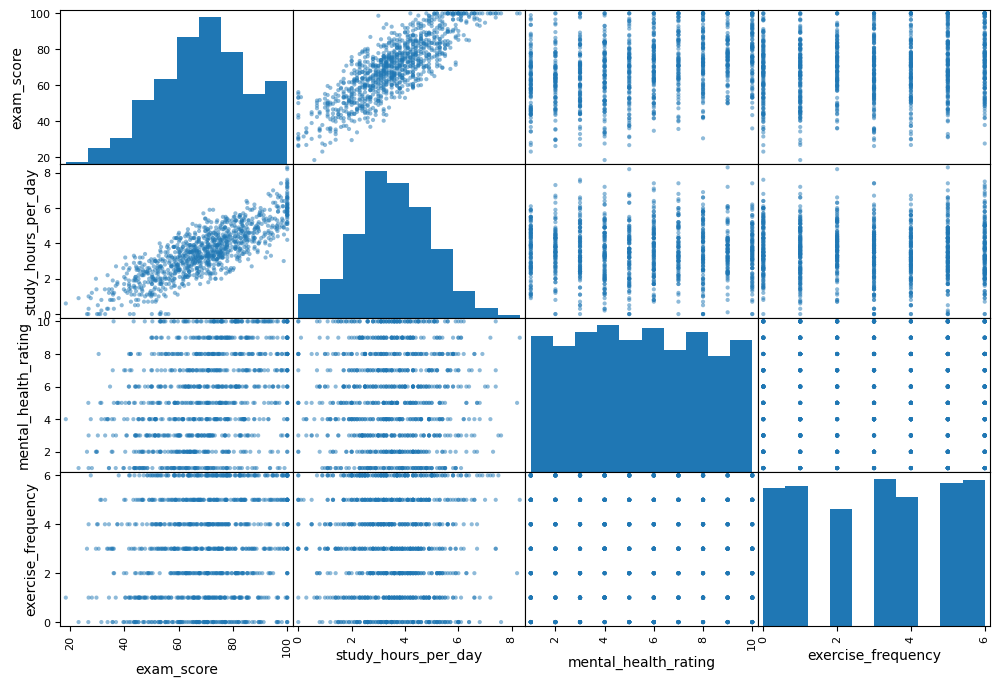

In [ ]:
from pandas.plotting import scatter_matrix

attributes=["exam_score", "study_hours_per_day", "mental_health_rating", "exercise_frequency"]
scatter_matrix(performance[attributes], figsize=(12,8))

<Axes: xlabel='study_hours_per_day', ylabel='exam_score'>

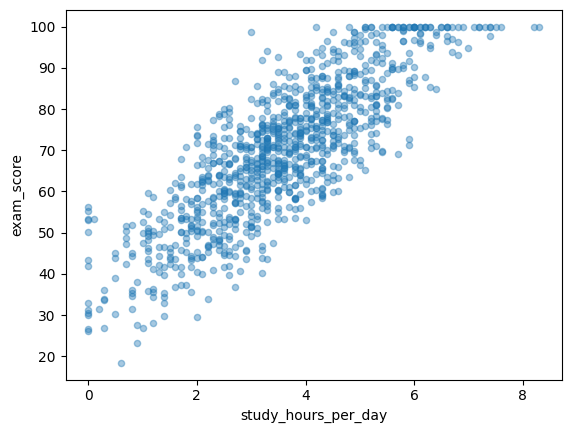

In [ ]:
performance.plot(kind="scatter", x="study_hours_per_day", y="exam_score", alpha=0.4)

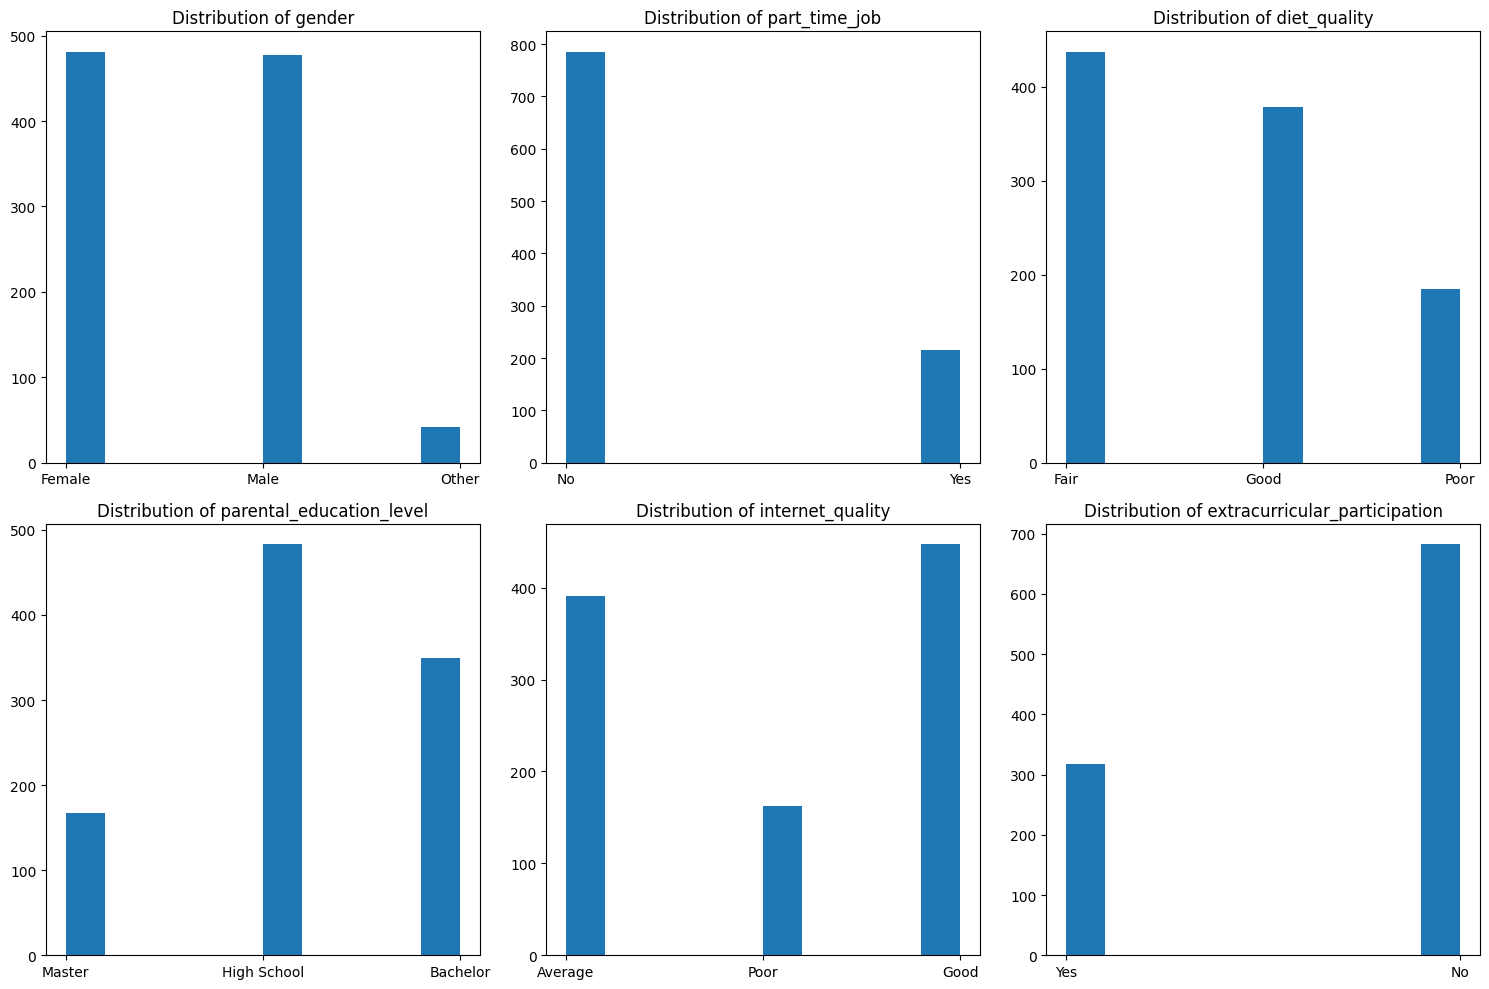

In [ ]:
plt.figure(figsize=(15,10)) # Increased figure size for better readability
categorical_col_names = categorical_columns.columns
categorical_col_names=[col for col in categorical_col_names]
categorical_col_names.remove("student_id")

for i in range(len(categorical_col_names)): # Iterate over the actual number of categorical columns
    plt.subplot(2, 3, i+1)  # Adjust subplot grid to 2 rows and 4 columns
    col_name = categorical_col_names[i]
    plt.hist(performance[col_name])
    plt.title(f'Distribution of {col_name}')

plt.tight_layout()

In [ ]:
categorical_columns=performance.select_dtypes(include=['object'])
numerical_columns=performance.select_dtypes(exclude=['object'])

In [ ]:
categorical_columns.drop("student_id", axis=1, inplace=True)
categorical_columns

,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
0,Female,No,Fair,Master,Average,Yes
1,Female,No,Good,High School,Average,No
2,Male,No,Poor,High School,Poor,No
3,Female,No,Poor,Master,Good,Yes
4,Female,No,Fair,Master,Good,No
...,...,...,...,...,...,...
995,Female,No,Fair,High School,Good,Yes
996,Female,Yes,Poor,High School,Average,Yes
997,Male,No,Good,Bachelor,Good,Yes
998,Male,Yes,Fair,Bachelor,Average,No


In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()
categorical_columns_1hot=encoder.fit_transform(categorical_columns)
categorical_columns_1hot.toarray()

array([[1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 1., 1., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]])

In [ ]:
categories_frame=pd.DataFrame(categorical_columns_1hot.toarray(),
                              columns=encoder.get_feature_names_out())

categories_frame

,gender_Female,gender_Male,gender_Other,part_time_job_No,part_time_job_Yes,diet_quality_Fair,diet_quality_Good,diet_quality_Poor,parental_education_level_Bachelor,parental_education_level_High School,parental_education_level_Master,internet_quality_Average,internet_quality_Good,internet_quality_Poor,extracurricular_participation_No,extracurricular_participation_Yes
0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
996,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
997,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
998,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
performance_numerical=scaler.fit_transform(numerical_columns)

In [ ]:
performance["hours_category"]=pd.cut(performance['study_hours_per_day'],
                                     bins=[0,2,4,6,8,np.inf],
                                     labels=[1,2,3,4,5],
                                     include_lowest=True)

<Axes: xlabel='hours_category'>

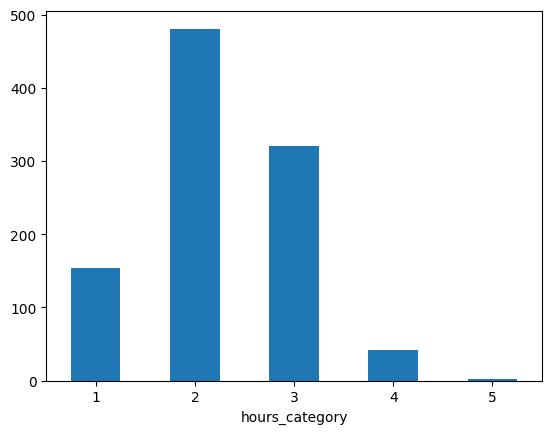

In [ ]:
performance["hours_category"].value_counts().sort_index().plot.bar(rot=0)

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter=StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_split=[]
for train_index, test_index in splitter.split(performance, performance["hours_category"]):
  strat_train_set=performance.loc[train_index]
  strat_test_set=performance.loc[test_index]
  strat_split.append((strat_train_set, strat_test_set))

strat_train_set, strat_test_set=strat_split[0]

In [ ]:
for set_ in (strat_train_set, strat_test_set):
  set_.drop("hours_category", axis=1, inplace=True)

In [ ]:
performance=strat_train_set.drop(["exam_score", "student_id"], axis=1)
performance_labels=strat_train_set["exam_score"].copy()
numerical_columns=performance.select_dtypes(exclude=['object'])
categorical_columns=performance.select_dtypes(include=['object'])

In [ ]:
X_test=strat_test_set.drop(["exam_score", "student_id"], axis=1)
y_test=strat_test_set["exam_score"].copy()

In [ ]:
from sklearn.pipeline import Pipeline, make_pipeline

In [ ]:
num_pipeleine=Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

In [ ]:
performance_num_prepared=num_pipeleine.fit_transform(numerical_columns)
performance_num_prepared[:2].round(2)

array([[-1.08,  0.25, -0.14, -1.67,  0.75, -0.79, -0.03, -1.56],
       [ 0.65, -0.3 ,  1.25, -0.47,  0.12,  1.25,  1.44,  0.9 ]])

In [ ]:
df_performance_num_prepared=pd.DataFrame(performance_num_prepared,
                                         columns=num_pipeleine.get_feature_names_out(),
                                         index=numerical_columns.index)
df_performance_num_prepared

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating
763,-1.083475,0.245606,-0.135747,-1.668325,0.753352,-0.790000,-0.027552,-1.558101
449,0.654430,-0.296047,1.248767,-0.465262,0.119063,1.246607,1.441892,0.902521
229,0.219954,-0.769993,0.989171,0.182542,1.140375,-0.545607,0.462262,-0.855066
101,-1.083475,0.042486,0.383446,0.089998,-0.644233,-1.604642,1.441892,0.199486
104,-1.083475,0.177899,0.643042,0.645258,0.635095,0.920750,0.952077,0.551003
...,...,...,...,...,...,...,...,...
116,-1.517952,2.344511,0.643042,1.200518,0.463084,-0.301214,0.952077,0.199486
200,1.088906,-0.025221,-1.087601,-1.205608,0.613593,1.083678,-0.517367,0.551003
133,0.219954,0.854965,-0.914537,0.367628,0.409331,-0.464143,0.462262,-1.206583
263,-1.517952,-0.905407,-0.135747,0.460172,1.097372,-0.301214,0.952077,0.199486


In [ ]:
cat_pipeline=Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder())
])

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
num_attribs=[cols for cols in numerical_columns.columns]
cat_attribs=[cols for cols in categorical_columns.columns]

In [ ]:
preprocessing=ColumnTransformer(
    [
        ("num", num_pipeleine, num_attribs),
        ("cat", cat_pipeline, cat_attribs),
    ]
)

In [ ]:
performance_prepared=preprocessing.fit_transform(performance)

In [ ]:
performance_prepared.shape

(800, 24)

In [ ]:
preprocessing.get_feature_names_out()

array(['num__age', 'num__study_hours_per_day', 'num__social_media_hours',
       'num__netflix_hours', 'num__attendance_percentage',
       'num__sleep_hours', 'num__exercise_frequency',
       'num__mental_health_rating', 'cat__gender_Female',
       'cat__gender_Male', 'cat__gender_Other', 'cat__part_time_job_No',
       'cat__part_time_job_Yes', 'cat__diet_quality_Fair',
       'cat__diet_quality_Good', 'cat__diet_quality_Poor',
       'cat__parental_education_level_Bachelor',
       'cat__parental_education_level_High School',
       'cat__parental_education_level_Master',
       'cat__internet_quality_Average', 'cat__internet_quality_Good',
       'cat__internet_quality_Poor',
       'cat__extracurricular_participation_No',
       'cat__extracurricular_participation_Yes'], dtype=object)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lin_reg=make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(performance, performance_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'study_hours_per_day',
                                                   'social_media_hours',
                                                   'netflix_hours',
                                                   'attendance_percentage',
                                                   'sleep_hours',
                                                   'exercise_frequency',
                                                   'mental_health_rating']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['gender', 'part_time_job',
                                                   'diet_quality',
                                                   'parental_education_level',
                                                   'internet_quality',
                                                   'extracurricular_participation'])])),
                ('linearregression', LinearRegression())])

In [ ]:
performance_prediction=lin_reg.predict(performance)

In [ ]:
performance_prediction[:5]

array([67.46461869, 74.89294368, 51.07748146, 69.30507108, 76.96226971])

In [ ]:
performance_labels[:5].values

array([59.5, 74. , 52.4, 74. , 74.3])

In [ ]:
from sklearn.metrics import root_mean_squared_error, r2_score

In [ ]:
lin_rmse=root_mean_squared_error(performance_labels, performance_prediction)
lin_rmse

5.186656977710538

In [ ]:
lin_r2=r2_score(performance_labels, performance_prediction)
lin_r2

0.9067216203863242

In [ ]:
performance_predictions=lin_reg.predict(X_test)

In [ ]:
performance_predictions[:5]

array([55.27793047, 52.49442079, 74.30523189, 63.05420427, 45.75550893])

In [ ]:
y_test[:5].values

array([61.2, 45. , 76.3, 66.8, 47.6])

In [ ]:
lin_rmses=root_mean_squared_error(y_test, performance_predictions)
lin_rmses

5.734089113949262

In [ ]:
linR2=r2_score(y_test, performance_predictions)
linR2

0.8786633953288545